# NBA Game Outcome Prediction Using Elo Ratings

This project builds a machine learning model to predict NBA game outcomes using Elo ratings and contextual features.

1. ## Data Source

This project uses the FiveThirtyEight NBA Elo dataset, which contains historical NBA games along with Elo ratings for both teams.

In [2]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd

gamefinder = leaguegamefinder.LeagueGameFinder(season_nullable="2023-24")
games = gamefinder.get_data_frames()[0]

# keep only regular season + playoffs for that season (safe filter)
games = games[games["SEASON_ID"] == "22023"]

print("Games rows:", len(games))
games[["GAME_ID", "GAME_DATE", "MATCHUP"]].head()



Games rows: 2460


,GAME_ID,GAME_DATE,MATCHUP
176,0022301192,2024-04-14,PHI vs. BKN
177,0022301197,2024-04-14,SAS vs. DET
178,0022301190,2024-04-14,NYK vs. CHI
179,0022301194,2024-04-14,PHX @ MIN
180,0022301199,2024-04-14,LAC vs. HOU


In [3]:
import requests, pandas as pd

test_game_id = games["GAME_ID"].iloc[0]
print("Testing GAME_ID:", test_game_id)

url = "https://stats.nba.com/stats/playbyplayv2"
params = {"GameID": test_game_id}

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://stats.nba.com/",
    "Origin": "https://stats.nba.com",
}

r = requests.get(url, headers=headers, params=params, timeout=30, allow_redirects=False)

print("Status:", r.status_code)
print("Location header:", r.headers.get("Location"))
print("Content-Type:", r.headers.get("Content-Type"))
print("Preview:", r.text[:200])







Testing GAME_ID: 0022301192
Status: 500
Location header: None
Content-Type: text/plain; charset=utf-8
Preview: System.InvalidOperationException: Nullable object must have a value.
   at StatsService.Models.PlayByPlayParameters.get_QueryParameters() in /source/StatsService/Models/PlayByPlayParameters.cs:line 49


In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context






In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv"
pbp = pd.read_csv(url)

pbp.head()



,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,...,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,...,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,...,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,...,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,...,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN


2. ## Data Exploration
We explore the dataset structure including number of rows, columns, and variable types.

In [6]:
# How big is the dataset?
print(pbp.shape)

# Column names
print(pbp.columns)

# Data types
print(pbp.dtypes)


(126314, 23)
Index(['gameorder', 'game_id', 'lg_id', '_iscopy', 'year_id', 'date_game',
       'seasongame', 'is_playoffs', 'team_id', 'fran_id', 'pts', 'elo_i',
       'elo_n', 'win_equiv', 'opp_id', 'opp_fran', 'opp_pts', 'opp_elo_i',
       'opp_elo_n', 'game_location', 'game_result', 'forecast', 'notes'],
      dtype='object')
gameorder          int64
game_id           object
lg_id             object
_iscopy            int64
year_id            int64
date_game         object
seasongame         int64
is_playoffs        int64
team_id           object
fran_id           object
pts                int64
elo_i            float64
elo_n            float64
win_equiv        float64
opp_id            object
opp_fran          object
opp_pts            int64
opp_elo_i        float64
opp_elo_n        float64
game_location     object
game_result       object
forecast         float64
notes             object
dtype: object


In [7]:
pbp.groupby("team_id")["pts"].mean().sort_values(ascending=False).head(10)


team_id
TEX    120.808989
DNA    119.639175
OAK    119.215116
PTC    119.148810
WSA    118.395604
SDR    114.736527
LAS    114.262570
CIN    114.216260
MMF    114.114943
MNP    113.976471
Name: pts, dtype: float64

3. ## Feature Engineering
We construct features used by the model.

In [8]:
# Create win/loss column from perspective of team_id
pbp["win"] = (pbp["pts"] > pbp["opp_pts"]).astype(int)

pbp[["team_id", "pts", "opp_pts", "win"]].head()


,team_id,pts,opp_pts,win
0,TRH,66,68,0
1,NYK,68,66,1
2,CHS,63,47,1
3,NYK,47,63,0
4,DTF,33,50,0


In [9]:
import pandas as pd

# 1 = home, 0 = away (usually "H" means home in these datasets)
pbp["home"] = (pbp["game_location"] == "H").astype(int)

# season already exists as year_id
pbp["season"] = pbp["year_id"]

features = ["elo_i", "opp_elo_i", "home", "season"]
X = pbp[features]
y = pbp["win"]

X.head(), y.head()


(       elo_i  opp_elo_i  home  season
 0  1300.0000  1300.0000     1    1947
 1  1300.0000  1300.0000     0    1947
 2  1300.0000  1306.7233     1    1947
 3  1306.7233  1300.0000     0    1947
 4  1300.0000  1300.0000     1    1947,
 0    0
 1    1
 2    1
 3    0
 4    0
 Name: win, dtype: int64)

4. ## Model Training
We train a logistic regression model to estimate win probability.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(101051, 4) (25263, 4)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [12]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.6781459050785734


In [13]:
import pandas as pd

importance = pd.DataFrame({
    "feature": features,
    "coef": model.coef_[0]
})

print(importance)


     feature      coef
0      elo_i  0.005740
1  opp_elo_i -0.005711
2       home  1.162094
3     season -0.000316


In [14]:
# Get predicted win probabilities for each game
win_probs = model.predict_proba(X)

# Probability that the team wins (class = 1)
pbp["win_prob"] = win_probs[:, 1]

pbp[["elo_i", "opp_elo_i", "home", "win", "win_prob"]].head()


,elo_i,opp_elo_i,home,win,win_prob
0,1300.0000,1300.0000,1,0,0.642243
1,1300.0000,1300.0000,0,1,0.359627
2,1300.0000,1306.7233,1,1,0.633373
3,1306.7233,1300.0000,0,0,0.368563
4,1300.0000,1300.0000,1,0,0.642243


In [15]:
# Convert probabilities into binary predictions
pbp["win_pred"] = (pbp["win_prob"] >= 0.5).astype(int)

pbp[["win", "win_prob", "win_pred"]].head(10)



,win,win_prob,win_pred
0,0,0.642243,1
1,1,0.359627,0
2,1,0.633373,1
3,0,0.368563,0
4,0,0.642243,1
5,1,0.359627,0
6,0,0.359627,0
7,1,0.642243,1
8,0,0.359627,0
9,1,0.642243,1


5. ## Model Evaluation
We evaluate model accuracy on unseen games.

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(pbp["win"], pbp["win_pred"])
accuracy


0.6809775638488212

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(pbp["win"], pbp["win_pred"])
cm


array([[43083, 20074],
       [20223, 42934]])

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and target
X = pbp[["elo_i", "opp_elo_i", "home", "season"]]
y = pbp["win"]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model on TRAIN data only
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on TEST data
y_pred = model.predict(X_test)

# Accuracy on unseen games
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy


0.6811146736333769

In [19]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

train_acc, test_acc


(0.6810422459945968, 0.6811146736333769)

6. ## Model Behavior Analysis
We analyze how predicted win probability changes with Elo rating difference.

In [20]:
pbp["elo_diff"] = pbp["elo_i"] - pbp["opp_elo_i"]

pbp[["elo_i", "opp_elo_i", "elo_diff", "win", "win_prob"]].head()


,elo_i,opp_elo_i,elo_diff,win,win_prob
0,1300.0000,1300.0000,0.0000,0,0.642243
1,1300.0000,1300.0000,0.0000,1,0.359627
2,1300.0000,1306.7233,-6.7233,1,0.633373
3,1306.7233,1300.0000,6.7233,0,0.368563
4,1300.0000,1300.0000,0.0000,0,0.642243


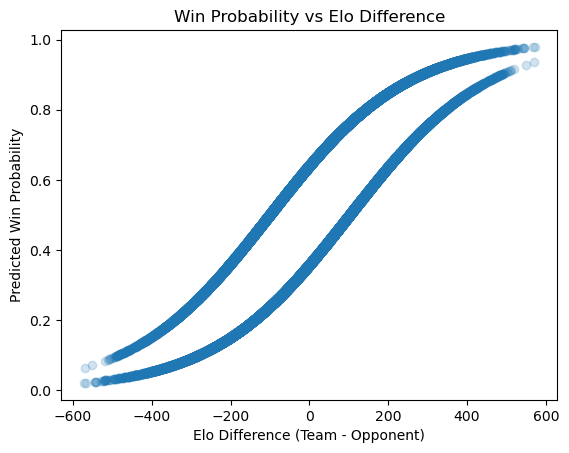

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pbp["elo_diff"], pbp["win_prob"], alpha=0.2)
plt.xlabel("Elo Difference (Team - Opponent)")
plt.ylabel("Predicted Win Probability")
plt.title("Win Probability vs Elo Difference")
plt.show()


7. ## Home Court Advantage Analysis
We compare predicted probabilities for home and away teams.

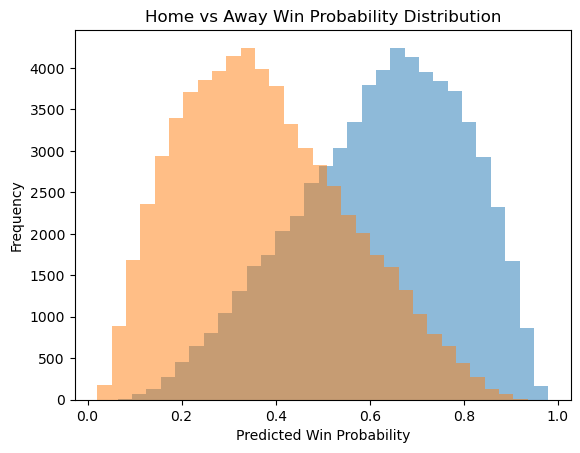

In [22]:
home_probs = pbp[pbp["home"] == 1]["win_prob"]
away_probs = pbp[pbp["home"] == 0]["win_prob"]

plt.figure()
plt.hist(home_probs, alpha=0.5, bins=30)
plt.hist(away_probs, alpha=0.5, bins=30)
plt.xlabel("Predicted Win Probability")
plt.ylabel("Frequency")
plt.title("Home vs Away Win Probability Distribution")
plt.show()


C:\Users\dd801\AppData\Local\Temp\ipykernel_48736\1521877907.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = pbp.groupby("prob_bin")["win"].mean()


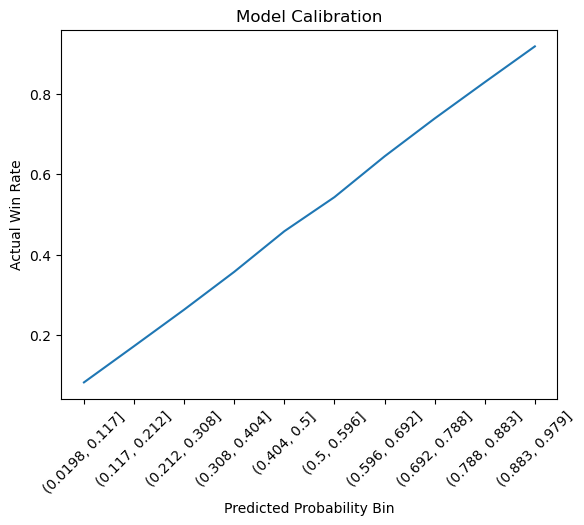

In [23]:
pbp["prob_bin"] = pd.cut(pbp["win_prob"], bins=10)

calibration = pbp.groupby("prob_bin")["win"].mean()

plt.figure()
plt.plot(calibration.index.astype(str), calibration.values)
plt.xticks(rotation=45)
plt.xlabel("Predicted Probability Bin")
plt.ylabel("Actual Win Rate")
plt.title("Model Calibration")
plt.show()


8. ## Baseline Model

We compare the machine learning model to a simple baseline prediction: the team with the higher Elo rating wins.

In [24]:
# Baseline prediction: higher Elo wins
pbp["elo_baseline_pred"] = (pbp["elo_i"] > pbp["opp_elo_i"]).astype(int)

# Baseline accuracy
from sklearn.metrics import accuracy_score

baseline_acc = accuracy_score(pbp["win"], pbp["elo_baseline_pred"])
baseline_acc


0.6432857798818816

In [25]:
# Model was very confident (>= 0.75) but wrong
high_conf_mistakes = pbp[
    ((pbp["win_prob"] >= 0.75) & (pbp["win"] == 0)) |
    ((pbp["win_prob"] <= 0.25) & (pbp["win"] == 1))
]

high_conf_mistakes[
    ["elo_i", "opp_elo_i", "home", "win", "win_prob"]
].head(10)


,elo_i,opp_elo_i,home,win,win_prob
222,1224.4557,1316.9688,0,1,0.248327
223,1316.9688,1224.4557,1,0,0.752868
284,1253.9355,1350.6637,0,1,0.244021
285,1350.6637,1253.9355,1,0,0.757501
328,1322.4481,1222.4307,1,0,0.760784
329,1222.4307,1322.4481,0,1,0.240403
387,1361.5421,1271.6172,1,0,0.750352
480,1228.9891,1403.6147,0,1,0.171309
481,1403.6147,1228.9891,1,0,0.829977
604,1420.7969,1304.9910,1,0,0.777307


In [26]:
pbp["correct"] = (pbp["win"] == pbp["win_pred"]).astype(int)

pbp["elo_diff_bin"] = pd.cut(pbp["elo_diff"], bins=10)

error_rate_by_elo = (
    pbp.groupby("elo_diff_bin")["correct"]
       .mean()
       .reset_index(name="accuracy")
)

error_rate_by_elo


C:\Users\dd801\AppData\Local\Temp\ipykernel_48736\3891154709.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbp.groupby("elo_diff_bin")["correct"]


,elo_diff_bin,accuracy
0,"(-573.305, -457.729]",0.910714
1,"(-457.729, -343.297]",0.886218
2,"(-343.297, -228.864]",0.814441
3,"(-228.864, -114.432]",0.700706
4,"(-114.432, 0.0]",0.636271
5,"(0.0, 114.432]",0.635507
6,"(114.432, 228.864]",0.700706
7,"(228.864, 343.297]",0.814441
8,"(343.297, 457.729]",0.886218
9,"(457.729, 572.161]",0.910714


## Model Behavior Insights

The model performs strongest when there is a large Elo difference between teams, achieving ~91% accuracy for large favorites and large underdogs. Performance drops to ~63% for evenly matched teams, indicating that Elo alone cannot capture variance-driven outcomes such as shooting efficiency, injuries, coaching strategy, and late-game execution.


## Basketball Interpretation

Games between evenly matched teams are harder to predict because outcomes are influenced by non-rating factors such as:
- Player injuries
- Shooting variance
- Matchup mismatches
- Coaching decisions
- Home crowd momentum
- Late-game execution

This shows that Elo is a strong baseline predictor but insufficient alone for close-match prediction.


## Model Limitations

Current model limitations:
- Uses only Elo and home-court advantage
- Does not include:
  - Player-level data
  - Injury reports
  - Rest days / back-to-backs
  - Pace of play
  - Offensive/defensive efficiency
  - Lineup matchups

These limitations explain reduced performance in evenly matched games.


## Future Improvements

Planned extensions:
- Add player-level impact metrics
- Integrate injury data
- Include rest-day and travel fatigue variables
- Add team offensive/defensive efficiency
- Use rolling performance metrics
- Try non-linear models (XGBoost, Random Forest)


## Project Goal

This project demonstrates how a simple Elo-based logistic regression model can be used to predict NBA game outcomes and analyze model confidence, reliability, and failure zones. The project focuses not only on prediction accuracy but on understanding model behavior and limitations, which is critical for real-world sports analytics applications.


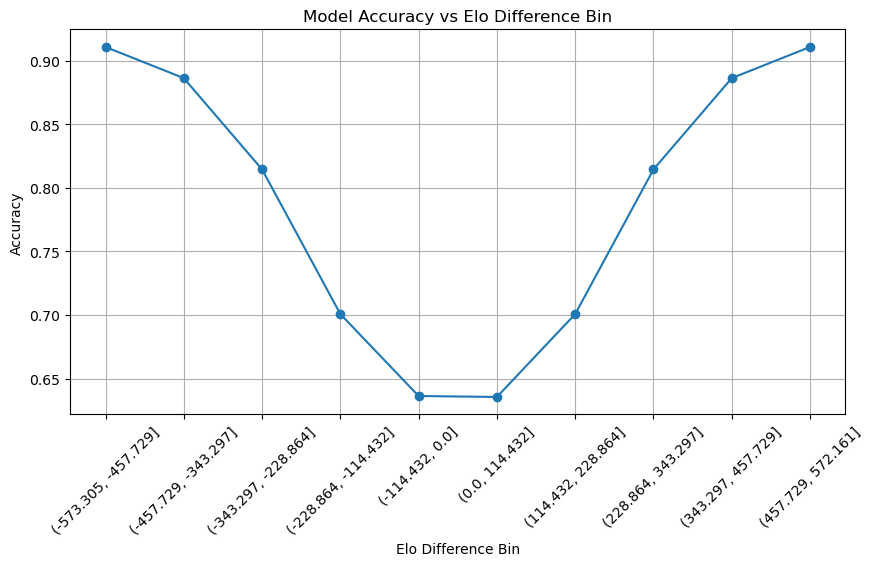

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(error_rate_by_elo["elo_diff_bin"].astype(str),
         error_rate_by_elo["accuracy"],
         marker="o")

plt.xticks(rotation=45)
plt.title("Model Accuracy vs Elo Difference Bin")
plt.xlabel("Elo Difference Bin")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [28]:
import numpy as np

pbp["confidence_bin"] = pd.cut(pbp["win_prob"], bins=10)

calibration = (
    pbp.groupby("confidence_bin")["correct"]
    .mean()
    .reset_index(name="accuracy")
)

calibration


C:\Users\dd801\AppData\Local\Temp\ipykernel_48736\2414168869.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbp.groupby("confidence_bin")["correct"]


,confidence_bin,accuracy
0,"(0.0198, 0.117]",0.917843
1,"(0.117, 0.212]",0.827701
2,"(0.212, 0.308]",0.736856
3,"(0.308, 0.404]",0.642781
4,"(0.404, 0.5]",0.541866
5,"(0.5, 0.596]",0.543023
6,"(0.596, 0.692]",0.644382
7,"(0.692, 0.788]",0.738604
8,"(0.788, 0.883]",0.828897
9,"(0.883, 0.979]",0.918006


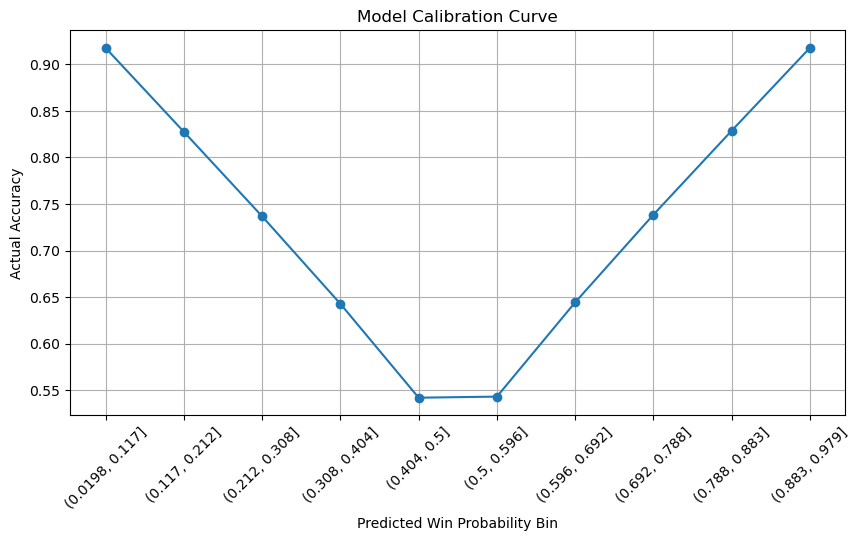

In [29]:
plt.figure(figsize=(10,5))
plt.plot(calibration["confidence_bin"].astype(str),
         calibration["accuracy"],
         marker="o")

plt.xticks(rotation=45)
plt.title("Model Calibration Curve")
plt.xlabel("Predicted Win Probability Bin")
plt.ylabel("Actual Accuracy")
plt.grid(True)
plt.show()
